In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/deployment_data.csv")

df.head()

,systems_impacted,num_files_changed,deployment_hour,deployment_day,engineer_experience,historical_failures,dependency_count,rollback_required,test_coverage,change_type,change_failed
0,7,41,0,Thursday,4,3,3,0,83,Application,0
1,4,50,1,Thursday,12,5,10,1,88,Infrastructure,1
2,13,87,2,Friday,9,0,10,0,55,Infrastructure,1
3,11,71,8,Monday,9,5,2,1,89,Database,0
4,8,59,4,Wednesday,3,3,7,0,96,Application,0


In [2]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (10000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   systems_impacted     10000 non-null  int64 
 1   num_files_changed    10000 non-null  int64 
 2   deployment_hour      10000 non-null  int64 
 3   deployment_day       10000 non-null  object
 4   engineer_experience  10000 non-null  int64 
 5   historical_failures  10000 non-null  int64 
 6   dependency_count     10000 non-null  int64 
 7   rollback_required    10000 non-null  int64 
 8   test_coverage        10000 non-null  int64 
 9   change_type          10000 non-null  object
 10  change_failed        10000 non-null  int64 
dtypes: int64(9), object(2)
memory usage: 859.5+ KB


,systems_impacted,num_files_changed,deployment_hour,engineer_experience,historical_failures,dependency_count,rollback_required,test_coverage,change_failed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.494300,49.955800,11.513200,7.602500,2.50070,5.490800,0.498200,70.082200,0.350000
std,4.031823,28.494572,6.918194,3.989998,1.70179,3.425768,0.500022,17.495681,0.476993
min,1.000000,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,40.000000,0.000000
25%,4.000000,25.000000,6.000000,4.000000,1.00000,3.000000,0.000000,55.000000,0.000000
50%,7.000000,50.000000,12.000000,8.000000,3.00000,6.000000,0.000000,70.000000,0.000000
75%,11.000000,75.000000,17.000000,11.000000,4.00000,8.000000,1.000000,85.000000,1.000000
max,14.000000,99.000000,23.000000,14.000000,5.00000,11.000000,1.000000,100.000000,1.000000


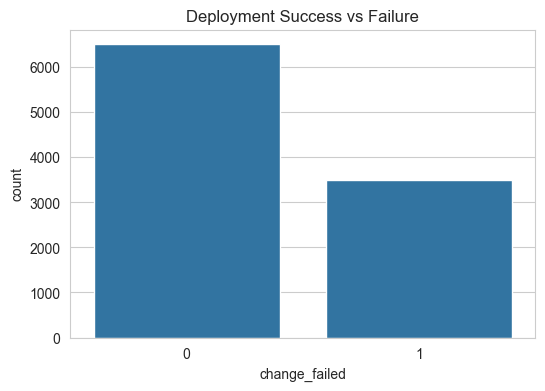

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="change_failed"
)

plt.title("Deployment Success vs Failure")

# plt.savefig("../reports/success_vs_failure.png", bbox_inches="tight")
plt.show()

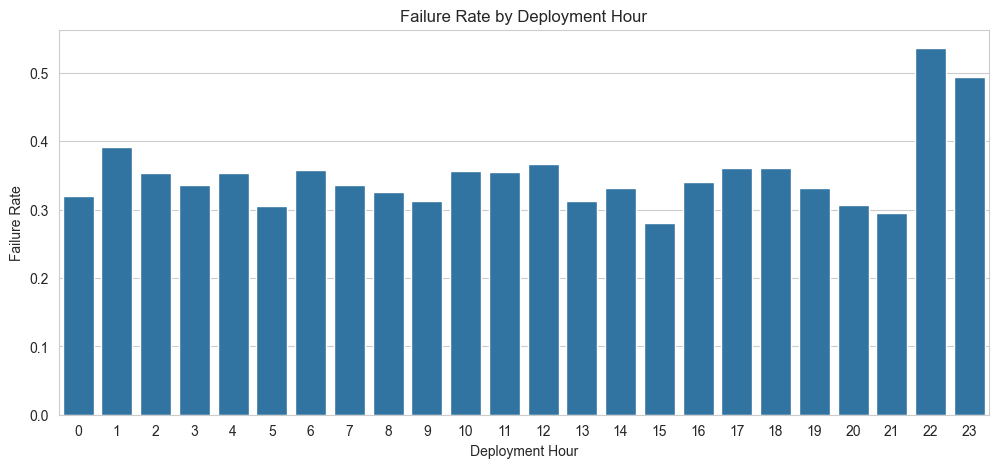

In [14]:
hourly_failures = (
    df.groupby("deployment_hour")["change_failed"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=hourly_failures,
    x="deployment_hour",
    y="change_failed"
)

plt.title("Failure Rate by Deployment Hour")
plt.ylabel("Failure Rate")
plt.xlabel("Deployment Hour")

# plt.show()
# plt.savefig("../reports/failure_by_hour.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

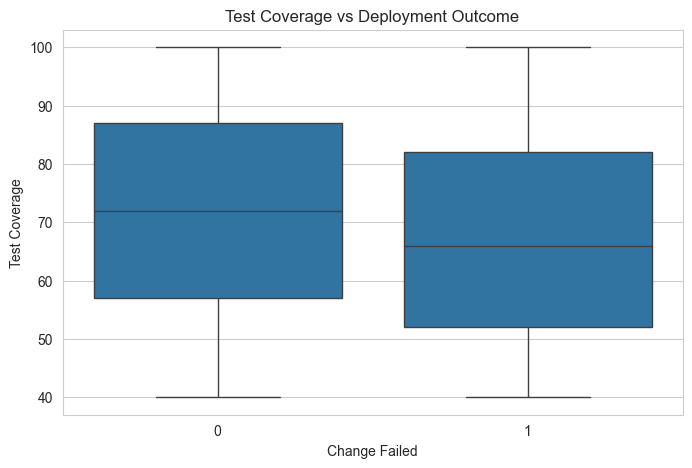

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="change_failed",
    y="test_coverage"
)

plt.title("Test Coverage vs Deployment Outcome")

plt.xlabel("Change Failed")
plt.ylabel("Test Coverage")

# plt.savefig("../reports/test_coverage_vs_dep.png", bbox_inches="tight")

plt.show()

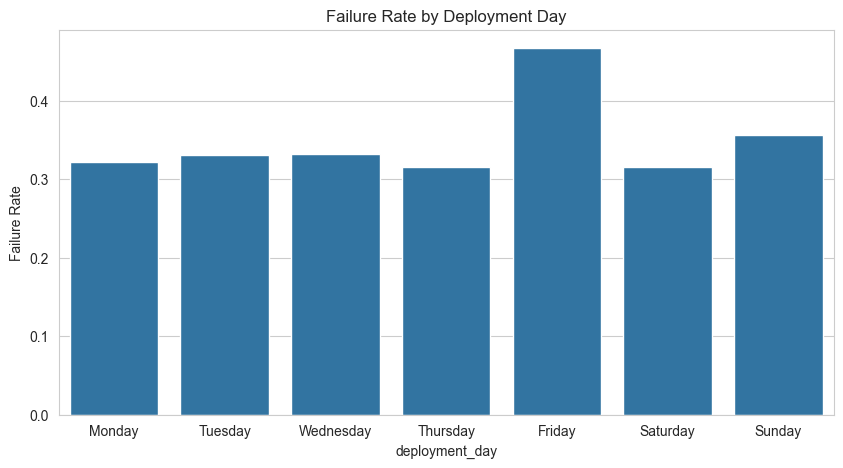

In [17]:
day_failure_rate = (
    df.groupby("deployment_day")["change_failed"]
      .mean()
      .reset_index()
)

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10,5))

sns.barplot(
    data=day_failure_rate,
    x="deployment_day",
    y="change_failed",
    order=order
)

plt.title("Failure Rate by Deployment Day")

plt.ylabel("Failure Rate")
# plt.savefig("../reports/failure_by_day.png", bbox_inches="tight")

plt.show()

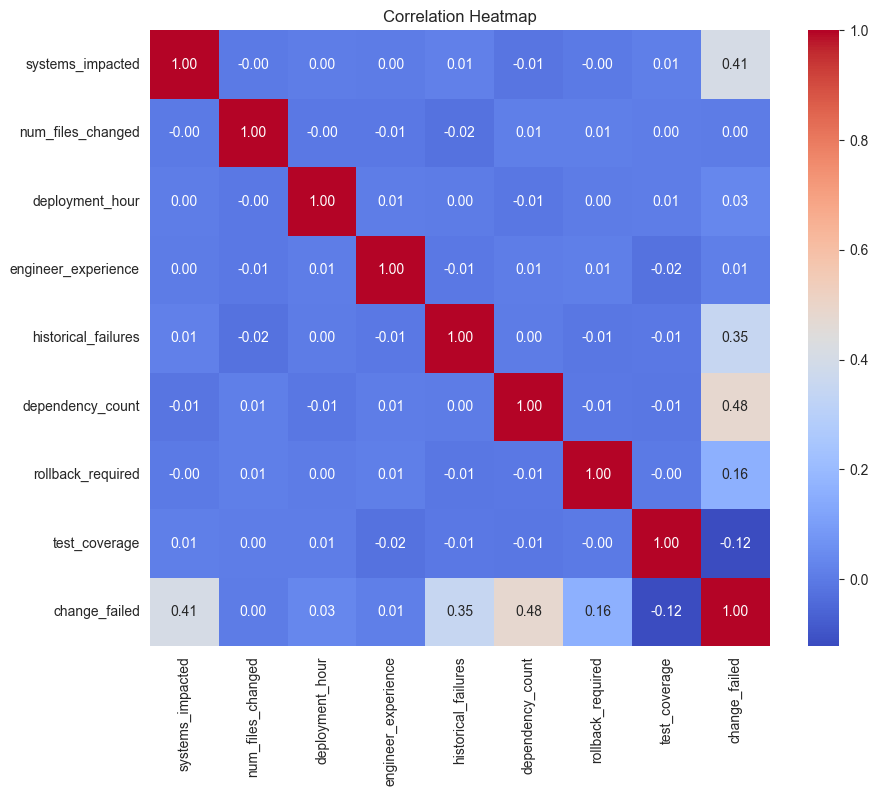

In [18]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

# plt.savefig("../reports/correlation_heatmap.png", bbox_inches="tight")

plt.show()

In [19]:
!pip install reportlab

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   --------------------- ------------------ 1.0/2.0 MB 5.5 MB/s eta 0:00:01
   ------------------------------------- -- 1.8/2.0 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 4.1 MB/s  0:00:00


In [20]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet

# Create PDF
pdf = SimpleDocTemplate("../reports/eda_report.pdf")

styles = getSampleStyleSheet()

content = []

# Title
content.append(
    Paragraph(
        "Exploratory Data Analysis Report - Deployment Risk Prediction",
        styles["Title"]
    )
)

content.append(Spacer(1, 20))

# Dataset Overview
content.append(
    Paragraph("1. Dataset Overview", styles["Heading1"])
)

content.append(
    Paragraph(
        f"Total Records: {len(df)}",
        styles["Normal"]
    )
)

failure_rate = round(
    df["change_failed"].mean() * 100,
    2
)

content.append(
    Paragraph(
        f"Failure Rate: {failure_rate}%",
        styles["Normal"]
    )
)

content.append(Spacer(1, 15))

# Failure by Hour
content.append(
    Paragraph(
        "2. Failure Rate by Deployment Hour",
        styles["Heading1"]
    )
)

content.append(
    Image(
        "../reports/failure_by_hour.png",
        width=450,
        height=250
    )
)

content.append(
    Paragraph(
        "This chart shows deployment hours with the highest failure rates.",
        styles["Normal"]
    )
)

content.append(PageBreak())

# Test Coverage
content.append(
    Paragraph(
        "3. Test Coverage Analysis",
        styles["Heading1"]
    )
)

content.append(
    Image(
        "../reports/test_coverage_vs_failure.png",
        width=450,
        height=250
    )
)

content.append(
    Paragraph(
        "Compare test coverage distributions between successful and failed deployments.",
        styles["Normal"]
    )
)

content.append(PageBreak())

# Failure by Day
content.append(
    Paragraph(
        "4. Failure Rate by Deployment Day",
        styles["Heading1"]
    )
)

content.append(
    Image(
        "../reports/failure_by_day.png",
        width=450,
        height=250
    )
)

content.append(
    Paragraph(
        "Friday and weekend deployments may show elevated risk.",
        styles["Normal"]
    )
)

content.append(PageBreak())

# Correlation Heatmap
content.append(
    Paragraph(
        "5. Correlation Analysis",
        styles["Heading1"]
    )
)

content.append(
    Image(
        "../reports/correlation_heatmap.png",
        width=450,
        height=350
    )
)

content.append(
    Paragraph(
        "The heatmap highlights relationships between numerical features and deployment failures.",
        styles["Normal"]
    )
)

content.append(Spacer(1, 20))

# Conclusion
content.append(
    Paragraph(
        "6. Conclusion",
        styles["Heading1"]
    )
)

content.append(
    Paragraph(
        """
        Key risk factors identified during EDA:
        <br/>
        • High dependency count
        <br/>
        • High historical failures
        <br/>
        • Low test coverage
        <br/>
        • Night-time deployments
        <br/>
        • Friday/weekend deployments
        """,
        styles["Normal"]
    )
)

# Build PDF
pdf.build(content)

print("EDA report generated successfully.")
print("Saved to: ../reports/eda_report.pdf")

EDA report generated successfully.
Saved to: ../reports/eda_report.pdf
